
# Predicción de abandono de clientes (Churn) con Regresión Logística

En este notebook vas a construir un modelo **introductorio** de *churn prediction* usando **scikit-learn**.

Aprenderás a:
1. Cargar y explorar datos de churn
2. Separar en entrenamiento y prueba de forma correcta
3. Construir un **Pipeline** con **ColumnTransformer** para preprocesar variables numéricas y categóricas
4. Entrenar una **Regresión Logística**
5. Evaluar el modelo con métricas apropiadas
6. Probar cambios y explicar qué ocurrió (ejercicios al final)

> Nota: en problemas de churn normalmente hay clases desbalanceadas. En este notebook **no asumimos** que balancear siempre mejora: lo comprobamos con métricas.



## 0. Descarga / disponibilidad del dataset

Este ejemplo está basado en un dataset de churn clásico (archivo `data.csv`).  
Si ya tienes el archivo en la misma carpeta del notebook, **puedes saltarte** la descarga.

Si estás en Colab, puedes usar `wget` para descargarlo (puede tardar unos segundos).


In [2]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1d6iPtgmKM5N2mtrWFb-SzLdGCwLWmxF9' -O data.csv

--2026-02-23 15:50:36--  https://docs.google.com/uc?export=download&id=1d6iPtgmKM5N2mtrWFb-SzLdGCwLWmxF9
Resolving docs.google.com (docs.google.com)... 74.125.135.139, 74.125.135.138, 74.125.135.102, ...
Connecting to docs.google.com (docs.google.com)|74.125.135.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1d6iPtgmKM5N2mtrWFb-SzLdGCwLWmxF9&export=download [following]
--2026-02-23 15:50:36--  https://drive.usercontent.google.com/download?id=1d6iPtgmKM5N2mtrWFb-SzLdGCwLWmxF9&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.195.132, 2607:f8b0:400e:c09::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.195.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [application/octet-stream]
Saving to: ‘data.csv’

data.csv            100%[===================>] 954.59K  --.-KB/s    in 0.008


## 1. Importar librerías


In [3]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    auc,
)
import matplotlib.pyplot as plt



## 2. Cargar los datos


In [4]:
df = pd.read_csv("data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)


### 2.1 Variable objetivo (target)

En churn, el target suele ser algo como:
- `Churn` (Yes/No)  
- `Exited` (0/1)  
- `Attrition` (0/1)  

Vamos a detectar automáticamente una columna objetivo razonable **si existe**.  
Si tu dataset usa otro nombre, ajústalo manualmente.


In [6]:
# Posibles nombres comunes de la variable objetivo
candidatas = ["Churn", "churn", "Exited", "exited", "Attrition", "attrition", "target", "Target", "y"]

target_col = None
for c in candidatas:
    if c in df.columns:
        target_col = c
        break

target_col

'Churn'

In [7]:
if target_col is None:
    raise ValueError(
        "No pude identificar la columna objetivo automáticamente. "
        "Define target_col manualmente, por ejemplo: target_col = 'Churn'."
    )

# Mostramos distribución de clases (muy importante en churn)
df[target_col].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869



## 3. Separar features (X) y target (y)

- `X`: variables predictoras
- `y`: la variable objetivo

También vamos a crear un **split estratificado** para que la proporción de clases se conserve en train y test.


In [8]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Si el target es texto (Yes/No), lo convertimos a 0/1 de manera sencilla
if y.dtype == "object":
    y = y.astype(str).str.strip().str.lower()
    if set(y.unique()) <= {"yes", "no"}:
        y = y.map({"no": 0, "yes": 1})
    elif set(y.unique()) <= {"true", "false"}:
        y = y.map({"false": 0, "true": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Churn
 0    0.734647
 1    0.265353
 Name: proportion, dtype: float64,
 Churn
 0    0.734564
 1    0.265436
 Name: proportion, dtype: float64)


## 4. Preprocesamiento con ColumnTransformer

Un `ColumnTransformer` te permite aplicar transformaciones diferentes según el tipo de columna:

- **Numéricas**: imputación (si faltan datos) + escalado
- **Categóricas**: imputación + One-Hot Encoding

Esto es el estándar en proyectos reales.


In [9]:
# Identificamos columnas por tipo
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

num_cols[:10], cat_cols[:10], (len(num_cols), len(cat_cols))

(['SeniorCitizen', 'tenure', 'MonthlyCharges'],
 ['customerID',
  'gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection'],
 (3, 17))

In [10]:
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols)
    ],
    remainder="drop"
)


## 5. Modelo: Regresión Logística (dentro del Pipeline)

La regresión logística es un modelo lineal muy usado por:
- simplicidad
- interpretabilidad básica
- buen desempeño como baseline

La entrenamos **dentro** del pipeline para garantizar que:
- el preproceso se ajuste solo con train
- el test permanezca “limpio”


In [11]:
logreg = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])
pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customerID', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression(max_iter=2000))])


## 6. Entrenamiento


In [12]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customerID', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression(max_iter=2000))])


## 7. Evaluación

Vamos a mirar:
- Matriz de confusión
- Precision / Recall / F1
- ROC-AUC (si aplica)
- PR-AUC (útil cuando hay desbalance)


In [13]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8444    0.8860    0.8647      1035
           1     0.6347    0.5481    0.5882       374

    accuracy                         0.7963      1409
   macro avg     0.7395    0.7171    0.7265      1409
weighted avg     0.7887    0.7963    0.7913      1409



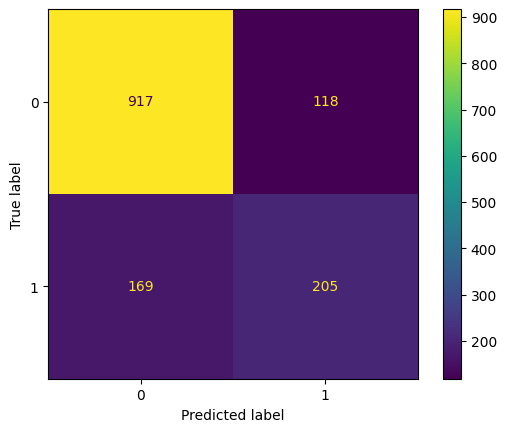

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

ROC-AUC: 0.8402903717481722


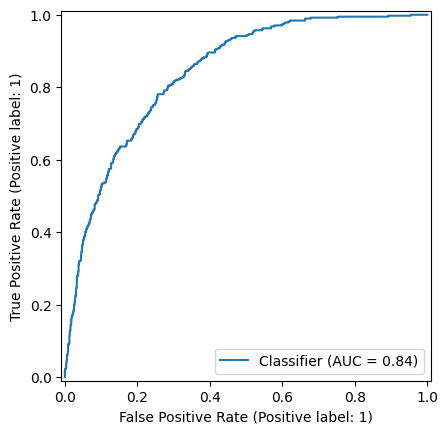

PR-AUC: 0.6329698953851168


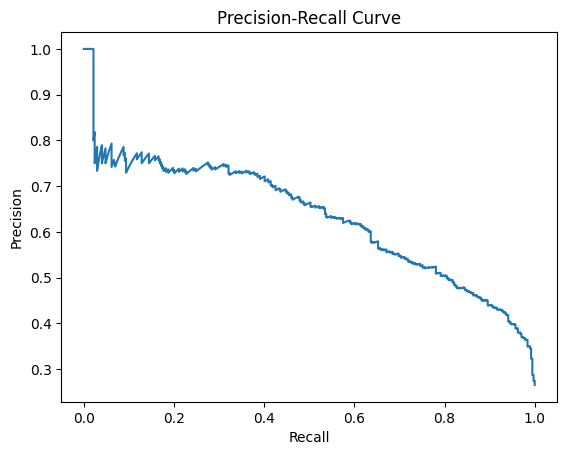

In [15]:
# ROC-AUC (si el modelo puede producir probabilidades)
if hasattr(pipe, "predict_proba"):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", roc)

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.show()

    # PR-AUC
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec)
    print("PR-AUC:", pr_auc)

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()
else:
    print("Este pipeline no expone predict_proba; omito ROC/PR curvas.")


## 8. ¿Balancear clases? (solo si tiene sentido)

En algunos datasets, usar `class_weight="balanced"` puede mejorar el **recall** de la clase minoritaria,
pero también puede **bajar la precisión** o empeorar el desempeño global.

Lo correcto es: **probar y comparar**.


In [16]:
pipe_bal = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced"))
])

pipe_bal.fit(X_train, y_train)
y_pred_bal = pipe_bal.predict(X_test)

print("=== Sin balanceo ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== Con class_weight='balanced' ===")
print(classification_report(y_test, y_pred_bal, digits=4))


=== Sin balanceo ===
              precision    recall  f1-score   support

           0     0.8444    0.8860    0.8647      1035
           1     0.6347    0.5481    0.5882       374

    accuracy                         0.7963      1409
   macro avg     0.7395    0.7171    0.7265      1409
weighted avg     0.7887    0.7963    0.7913      1409

=== Con class_weight='balanced' ===
              precision    recall  f1-score   support

           0     0.8842    0.7749    0.8260      1035
           1     0.5359    0.7193    0.6142       374

    accuracy                         0.7601      1409
   macro avg     0.7100    0.7471    0.7201      1409
weighted avg     0.7918    0.7601    0.7697      1409




## 9. Ejercicios propuestos (para entregar)

A continuación tienes ideas para experimentar. La idea NO es “adivinar”,
sino **cambiar una cosa, medir, y explicar con evidencia**.

### Ejercicio 1 — Cambiar el umbral de decisión
En vez de usar el umbral 0.5, prueba 0.3, 0.4, 0.6 y compara precision/recall.

### Ejercicio 2 — Quitar el escalado
En numéricas, elimina `StandardScaler()` y observa qué pasa (en regresión logística suele afectar).

### Ejercicio 3 — Cambiar la imputación
- numéricas: `median` vs `mean`
- categóricas: `most_frequent` vs una constante (por ejemplo `"missing"`)

### Ejercicio 4 — Regularización
Cambia el parámetro `C` (por ejemplo 0.1, 1, 10) y explica el efecto.

### Ejercicio 5 — Métrica objetivo
Elige una métrica que te interese (por ejemplo **recall** de churn) y ajusta el modelo para optimizarla.



### Plantilla para Ejercicio 1: umbral de decisión

Completa y comenta resultados.


In [17]:
# TODO: probar distintos umbrales y comparar métricas

if hasattr(pipe, "predict_proba"):
    y_proba = pipe.predict_proba(X_test)[:, 1]

    thresholds = [0.3, 0.4, 0.5, 0.6]
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        print(f"--- Umbral = {t} ---")
        print(classification_report(y_test, y_pred_t, digits=4))
else:
    print("El modelo no tiene predict_proba; no se puede hacer este ejercicio.")


--- Umbral = 0.3 ---
              precision    recall  f1-score   support

           0     0.8928    0.7565    0.8190      1035
           1     0.5263    0.7487    0.6181       374

    accuracy                         0.7544      1409
   macro avg     0.7096    0.7526    0.7186      1409
weighted avg     0.7955    0.7544    0.7657      1409

--- Umbral = 0.4 ---
              precision    recall  f1-score   support

           0     0.8679    0.8251    0.8460      1035
           1     0.5741    0.6524    0.6108       374

    accuracy                         0.7793      1409
   macro avg     0.7210    0.7388    0.7284      1409
weighted avg     0.7899    0.7793    0.7835      1409

--- Umbral = 0.5 ---
              precision    recall  f1-score   support

           0     0.8444    0.8860    0.8647      1035
           1     0.6347    0.5481    0.5882       374

    accuracy                         0.7963      1409
   macro avg     0.7395    0.7171    0.7265      1409
weighted av